In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use("ggplot")

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
# Load cleaned datasets

fund_master = pd.read_csv("../data/processed/cleaned_01_fund_master.csv")

nav_history = pd.read_csv("../data/processed/cleaned_nav_history.csv")

aum = pd.read_csv("../data/processed/cleaned_03_aum_by_fund_house.csv")

sip = pd.read_csv("../data/processed/cleaned_04_monthly_sip_inflows.csv")

category = pd.read_csv("../data/processed/cleaned_05_category_inflows.csv")

folio = pd.read_csv("../data/processed/cleaned_06_industry_folio_count.csv")

performance = pd.read_csv("../data/processed/cleaned_scheme_performance.csv")

transactions = pd.read_csv("../data/processed/cleaned_investor_transactions.csv")

holdings = pd.read_csv("../data/processed/cleaned_09_portfolio_holdings.csv")

benchmark = pd.read_csv("../data/processed/cleaned_10_benchmark_indices.csv")

print("All datasets loaded successfully")

All datasets loaded successfully


In [3]:
print("NAV HISTORY")
print(nav_history.columns)

print("\nAUM")
print(aum.columns)

print("\nSIP")
print(sip.columns)

print("\nCATEGORY")
print(category.columns)

print("\nTRANSACTIONS")
print(transactions.columns)

print("\nHOLDINGS")
print(holdings.columns)

NAV HISTORY
Index(['amfi_code', 'date', 'nav'], dtype='str')

AUM
Index(['date', 'fund_house', 'aum_lakh_crore', 'aum_crore', 'num_schemes'], dtype='str')

SIP
Index(['month', 'sip_inflow_crore', 'active_sip_accounts_crore',
       'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct'],
      dtype='str')

CATEGORY
Index(['month', 'category', 'net_inflow_crore'], dtype='str')

TRANSACTIONS
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

HOLDINGS
Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [4]:
# Convert date column to datetime

nav_history["date"] = pd.to_datetime(
    nav_history["date"]
)

# Plot NAV trends

fig = px.line(
    nav_history,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend (2022–2026)"
)

fig.update_layout(
    xaxis_title="Date",
    yaxis_title="NAV",
    height=600
)

fig.show()

### Insight 1:
Daily NAV trends across schemes show varying growth patterns, with noticeable market growth during the 2023 bull run and moderate corrections during 2024.

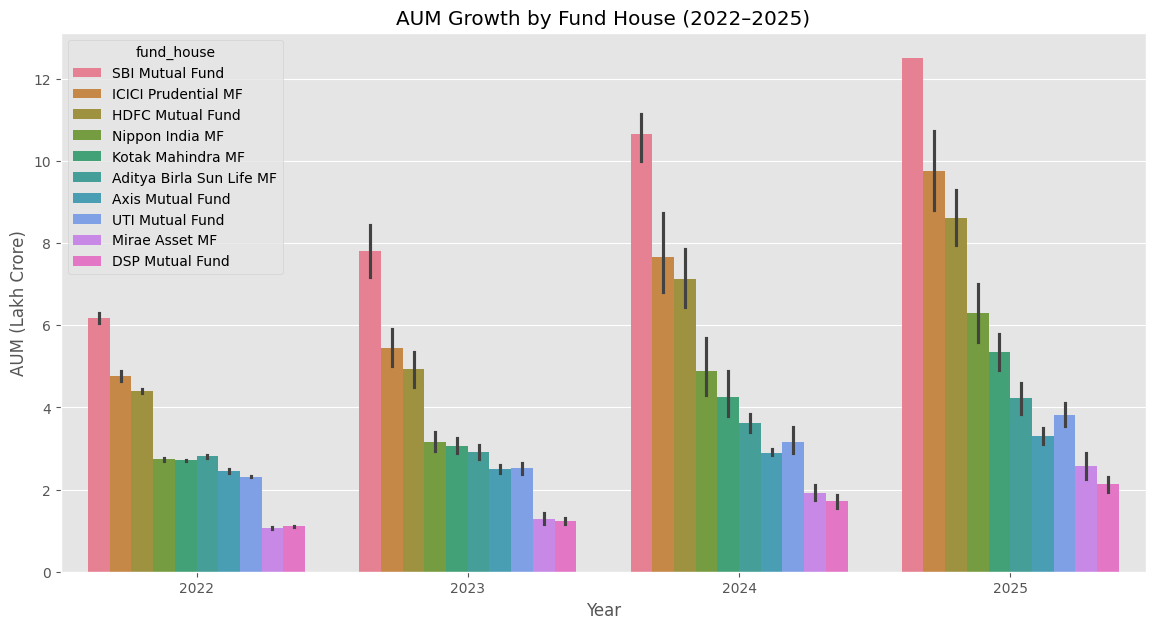

In [5]:
# Extract year

aum["date"] = pd.to_datetime(aum["date"])

aum["year"] = aum["date"].dt.year

# Grouped bar chart

plt.figure(figsize=(14,7))

sns.barplot(
    data=aum,
    x="year",
    y="aum_lakh_crore",
    hue="fund_house"
)

plt.title("AUM Growth by Fund House (2022–2025)")
plt.xlabel("Year")
plt.ylabel("AUM (Lakh Crore)")
plt.xticks(rotation=0)

plt.show()

### Insight 2:
Fund houses demonstrated steady AUM growth over time, with SBI Mutual Fund maintaining strong dominance in total assets under management.

In [6]:
# Convert month column

sip["month"] = pd.to_datetime(
    sip["month"]
)

# Plot SIP inflow trend

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflow Trend"
)

fig.update_layout(
    xaxis_title="Month",
    yaxis_title="SIP Inflow (Crore)"
)

fig.show()

### Insight 3:
Monthly SIP inflows showed consistent growth over time, indicating rising investor participation and confidence in systematic investments.

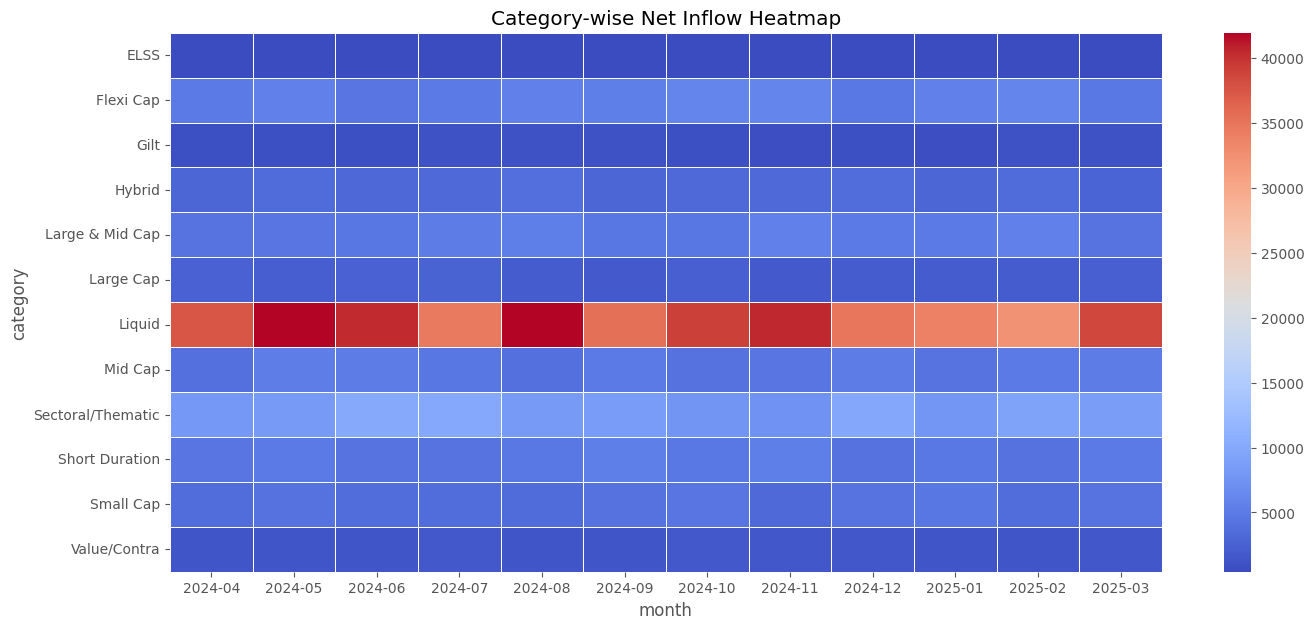

In [7]:
# Pivot table for heatmap

category_pivot = category.pivot_table(
    values="net_inflow_crore",
    index="category",
    columns="month",
    aggfunc="sum"
)

plt.figure(figsize=(16,7))

sns.heatmap(
    category_pivot,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Category-wise Net Inflow Heatmap")

plt.show()

### Insight 4:
Certain mutual fund categories consistently attracted higher inflows, reflecting changing investor preferences across market cycles.

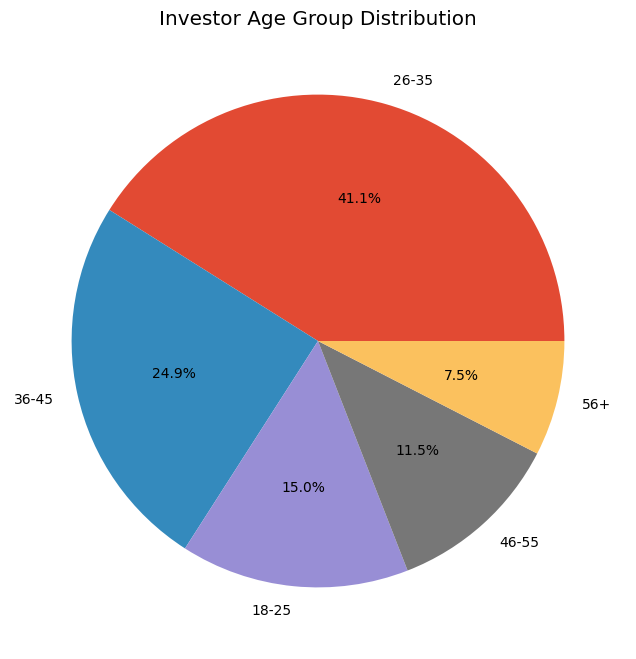

In [18]:
# Age group distribution

age_distribution = (
    transactions["age_group"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct="%1.1f%%"
)

plt.title("Investor Age Group Distribution")

plt.show()

### Insight 5:
Investor participation was concentrated in selected age groups, showing stronger investment activity among working-age individuals.

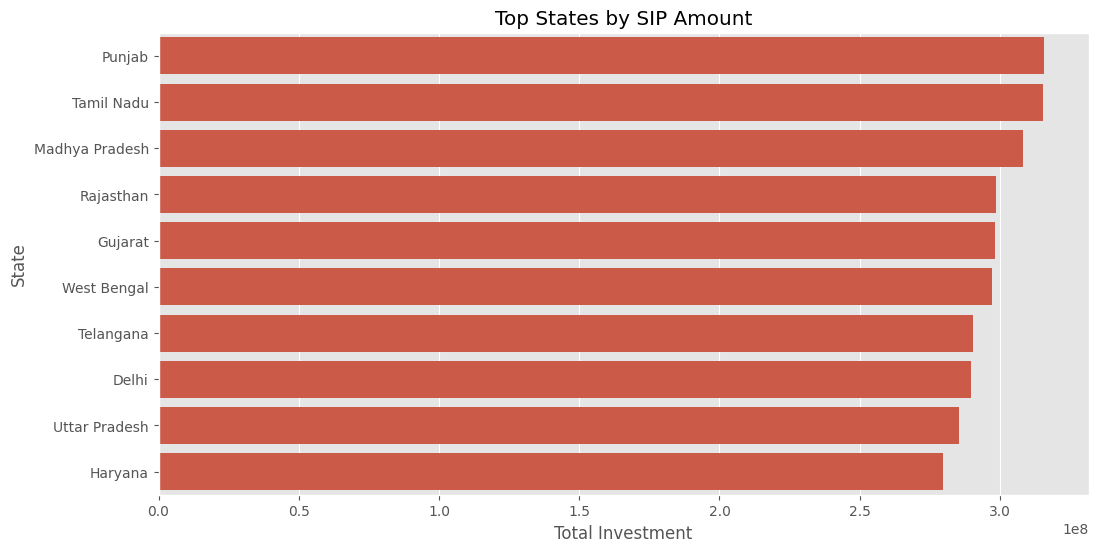

In [19]:
# Convert amount to numeric

transactions["amount_inr"] = pd.to_numeric(
    transactions["amount_inr"]
)

# State-wise investment amount

state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title("Top States by SIP Amount")

plt.xlabel("Total Investment")

plt.ylabel("State")

plt.show()

### Insight 6:
Investment activity was concentrated in a few major states, indicating stronger mutual fund participation in financially active regions.

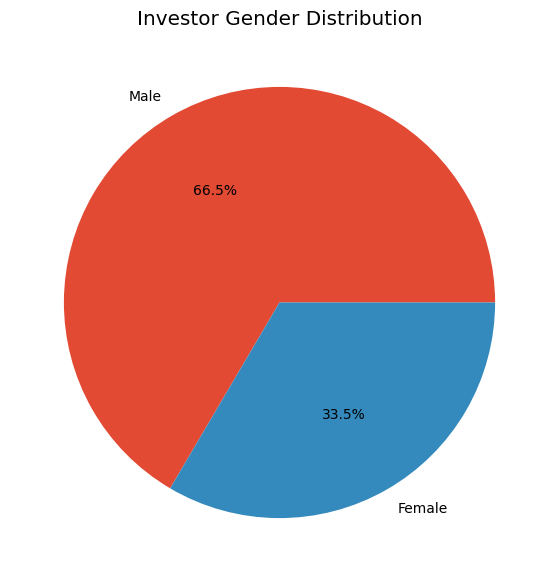

In [20]:
# Gender distribution

gender_distribution = (
    transactions["gender"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    gender_distribution,
    labels=gender_distribution.index,
    autopct="%1.1f%%"
)

plt.title("Investor Gender Distribution")

plt.show()

### Insight 7:
The investor base showed variation across gender participation, reflecting different levels of engagement in financial investments.

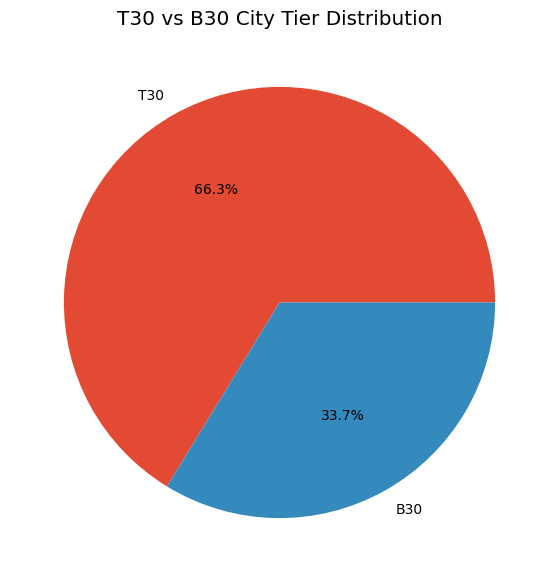

In [21]:
# City tier distribution

city_tier_distribution = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    city_tier_distribution,
    labels=city_tier_distribution.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 City Tier Distribution")

plt.show()

### Insight 8:
Metro and Tier-1 cities contributed significantly to investment participation, while B30 cities also showed growing engagement.

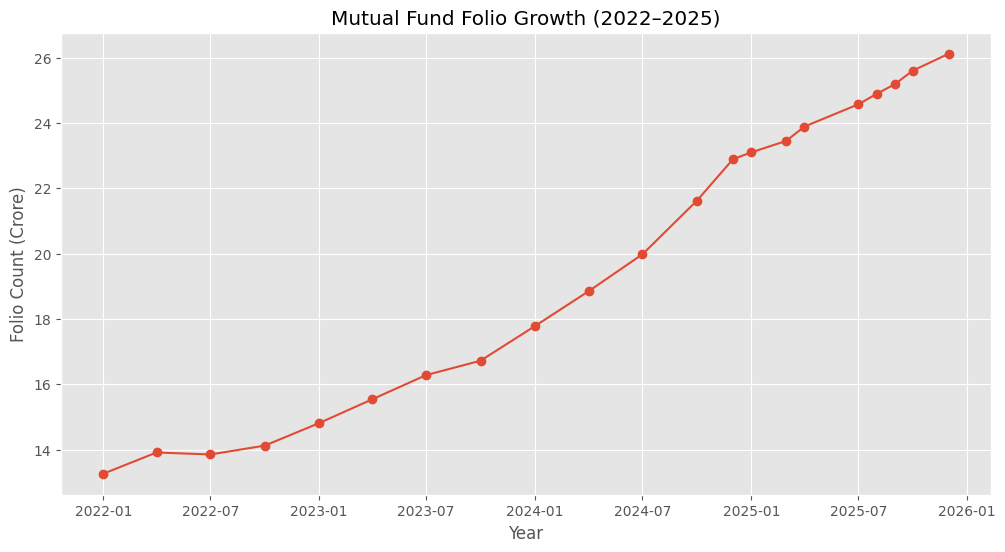

In [26]:
# Load folio data

folio = pd.read_csv(
    "../data/raw/06_industry_folio_count.csv"
)

# Convert month column

folio["month"] = pd.to_datetime(
    folio["month"]
)

# Convert folio count to numeric

folio["total_folios_crore"] = pd.to_numeric(
    folio["total_folios_crore"]
)

# Plot chart

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"],
    marker="o"
)

plt.title(
    "Mutual Fund Folio Growth (2022–2025)"
)

plt.xlabel("Year")

plt.ylabel("Folio Count (Crore)")

plt.show()

### Insight 9:
Mutual fund folio counts consistently increased from 2022 to 2025, reflecting growing retail investor participation.

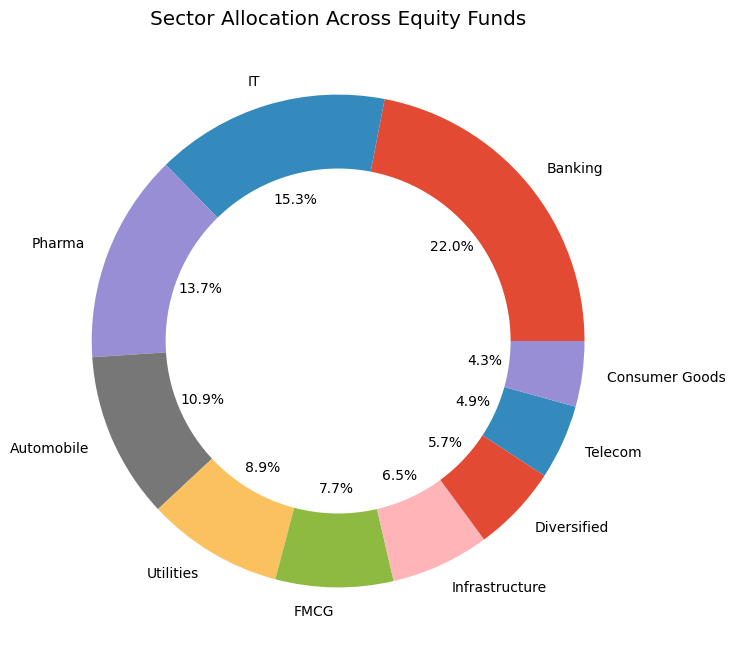

In [27]:
# Convert weight to numeric

holdings["weight_pct"] = pd.to_numeric(
    holdings["weight_pct"]
)

# Aggregate sector allocation

sector_weights = (
    holdings.groupby("sector")
    ["weight_pct"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8,8))

plt.pie(
    sector_weights,
    labels=sector_weights.index,
    autopct="%1.1f%%"
)

centre_circle = plt.Circle(
    (0,0),
    0.70,
    fc="white"
)

fig = plt.gcf()

fig.gca().add_artist(
    centre_circle
)

plt.title("Sector Allocation Across Equity Funds")

plt.show()

### Insight 10:
Portfolio allocation was concentrated in a few dominant sectors, indicating preference toward high-growth industries.

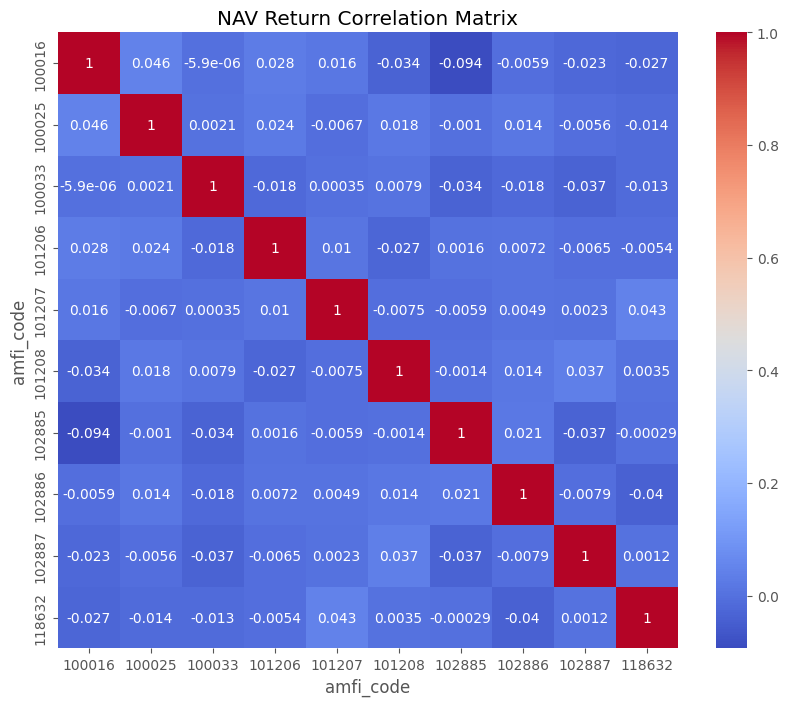

In [28]:
# Select 10 funds

selected_funds = (
    nav_history["amfi_code"]
    .unique()[:10]
)

nav_subset = nav_history[
    nav_history["amfi_code"]
    .isin(selected_funds)
]

# Pivot data

pivot_nav = nav_subset.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

# Daily returns

returns = pivot_nav.pct_change()

# Correlation matrix

corr_matrix = returns.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.show()

### Insight 11:
Several funds displayed positive return correlations, indicating common market movement patterns across schemes.

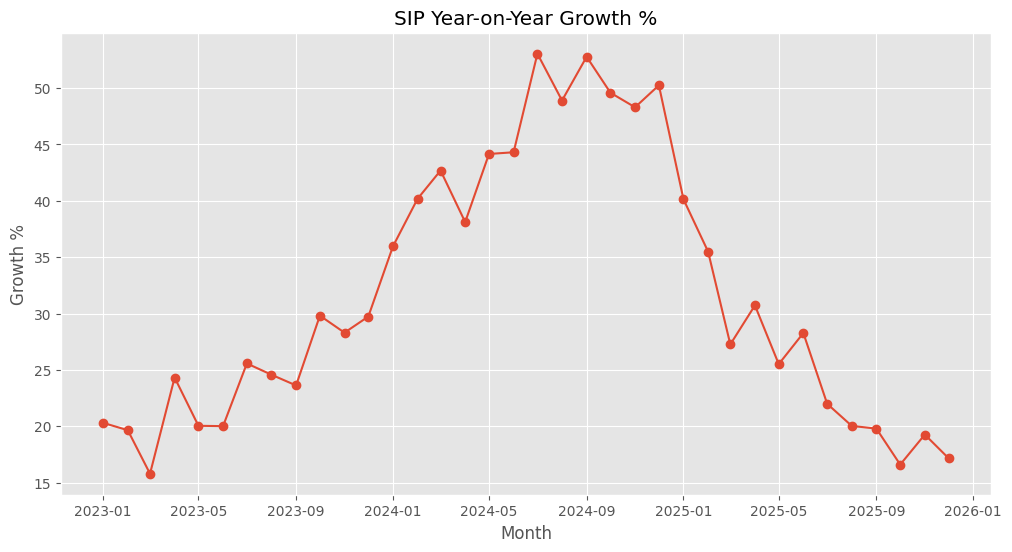

In [29]:
# Convert YoY growth

sip["yoy_growth_pct"] = pd.to_numeric(
    sip["yoy_growth_pct"]
)

plt.figure(figsize=(12,6))

plt.plot(
    sip["month"],
    sip["yoy_growth_pct"],
    marker="o"
)

plt.title("SIP Year-on-Year Growth %")

plt.xlabel("Month")
plt.ylabel("Growth %")

plt.show()

### Insight 12:
SIP growth remained positive over time, indicating growing investor confidence and systematic participation.

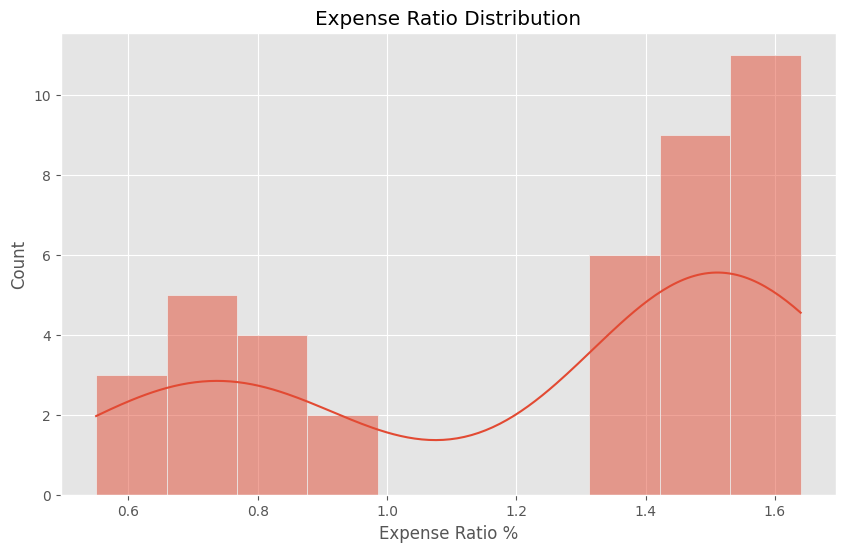

In [30]:
performance["expense_ratio_pct"] = pd.to_numeric(
    performance["expense_ratio_pct"]
)

plt.figure(figsize=(10,6))

sns.histplot(
    performance["expense_ratio_pct"],
    bins=10,
    kde=True
)

plt.title("Expense Ratio Distribution")

plt.xlabel("Expense Ratio %")

plt.show()

### Insight 13:
Most mutual fund schemes maintained expense ratios within a narrow range, reflecting industry-level cost consistency.

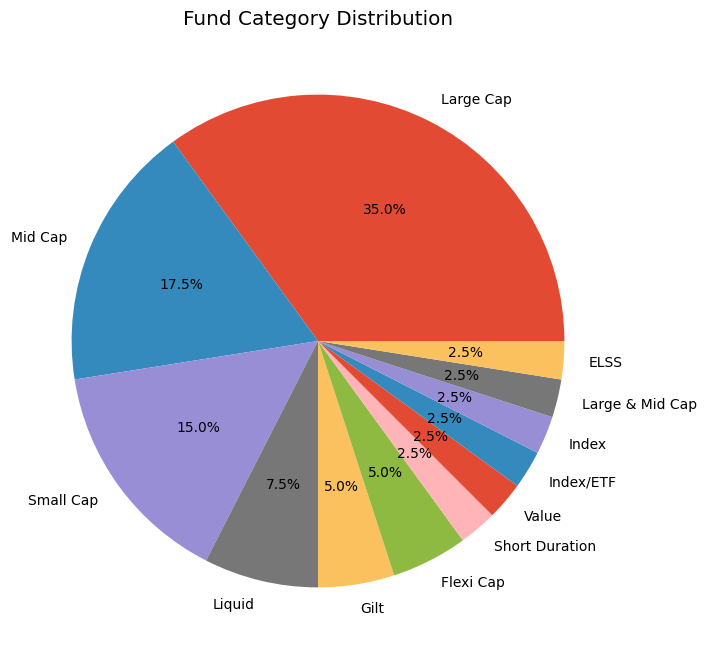

In [31]:
category_count = (
    performance["category"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    category_count,
    labels=category_count.index,
    autopct="%1.1f%%"
)

plt.title("Fund Category Distribution")

plt.show()

### Insight 14:
Mutual fund schemes were distributed across multiple investment categories, providing portfolio diversification opportunities.

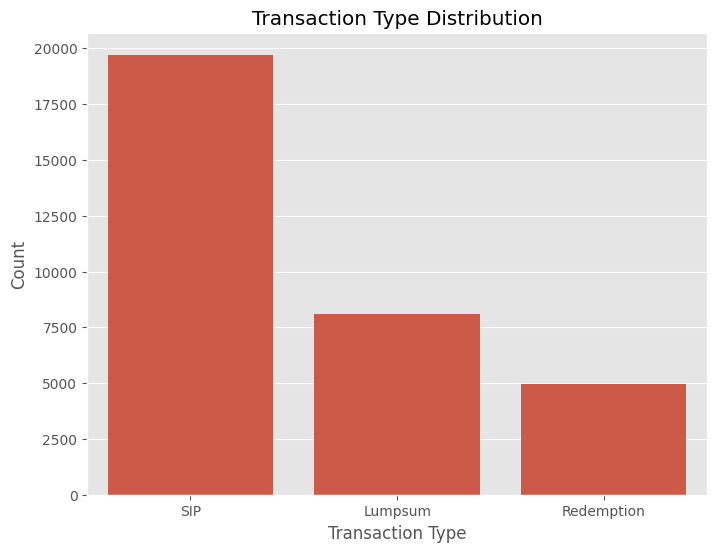

In [32]:
transaction_distribution = (
    transactions["transaction_type"]
    .value_counts()
)

plt.figure(figsize=(8,6))

sns.barplot(
    x=transaction_distribution.index,
    y=transaction_distribution.values
)

plt.title("Transaction Type Distribution")

plt.xlabel("Transaction Type")
plt.ylabel("Count")

plt.show()

### Insight 15:
SIP-based transactions represented a significant share of investor activity, highlighting long-term investment preference.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
transactions = pd.read_csv(
    "../data/processed/cleaned_investor_transactions.csv"
)

print(transactions.shape)

print(transactions.head())

(32778, 13)
  investor_id transaction_date  amfi_code transaction_type  amount_inr  \
0   INV003054       2024-01-01     119092              SIP        1834   
1   INV002952       2024-01-01     148567       REDEMPTION      392882   
2   INV003420       2024-01-01     118636              SIP         912   
3   INV003436       2024-01-01     118634              SIP        1102   
4   INV004691       2024-01-01     119094          LUMPSUM        8682   

         state       city city_tier age_group  gender  annual_income_lakh  \
0    Telangana  Hyderabad       T30       56+  Female                77.1   
1       Punjab   Amritsar       B30     18-25    Male                 7.1   
2      Haryana  Faridabad       B30     36-45    Male                47.2   
3  Maharashtra     Mumbai       T30     36-45  Female                54.4   
4        Delhi      Noida       T30     26-35    Male                14.5   

  payment_mode kyc_status  
0          UPI   Verified  
1       Cheque   Verifie

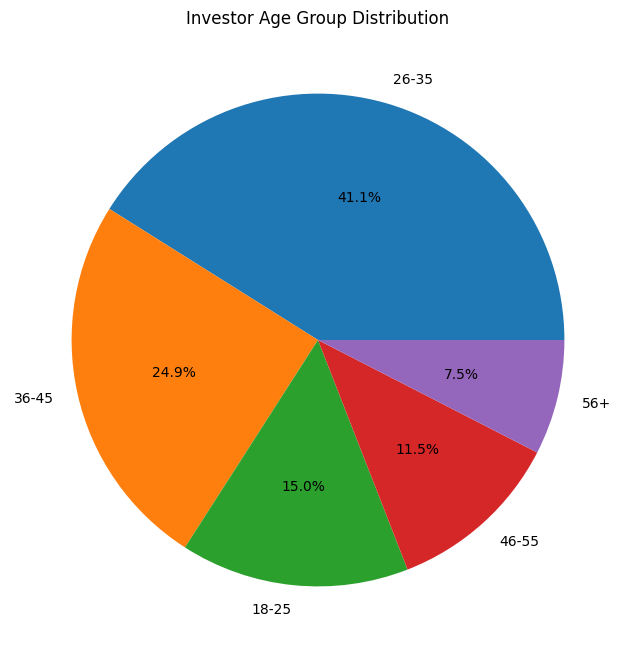

In [4]:
age_distribution = (
    transactions["age_group"]
    .value_counts()
)

plt.figure(figsize=(8,8))

plt.pie(
    age_distribution,
    labels=age_distribution.index,
    autopct="%1.1f%%"
)

plt.title(
    "Investor Age Group Distribution"
)

plt.show()

### Insight:
Investor participation was concentrated among working-age groups, indicating stronger mutual fund adoption among individuals in active earning years.

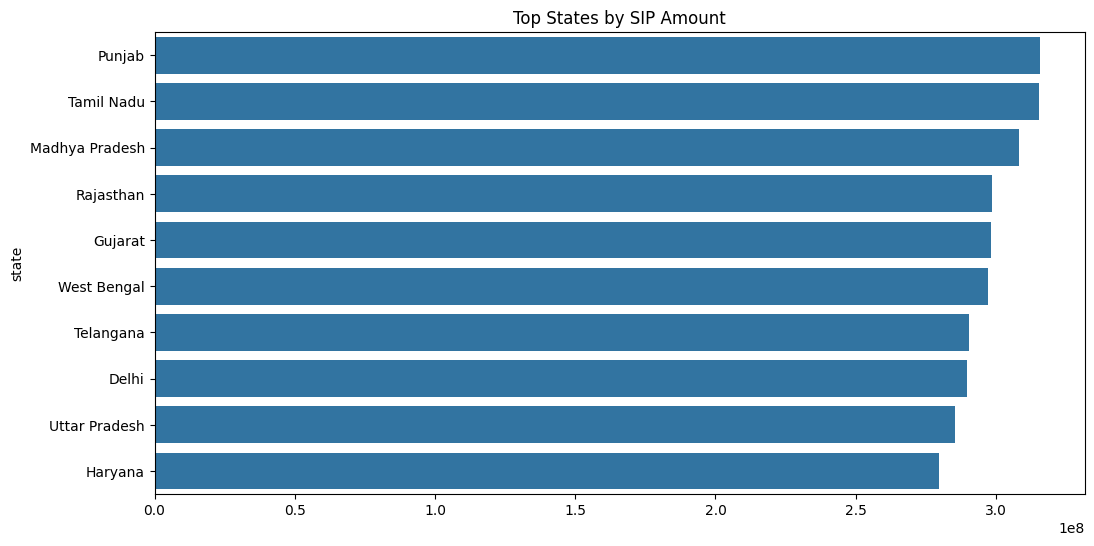

In [5]:
transactions["amount_inr"] = pd.to_numeric(
    transactions["amount_inr"]
)

state_amount = (
    transactions
    .groupby("state")["amount_inr"]
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=state_amount.values,
    y=state_amount.index
)

plt.title(
    "Top States by SIP Amount"
)

plt.show()

### Insight:
A few major states contributed a disproportionately higher share of SIP investments, reflecting stronger financial participation and investment awareness in economically active regions.

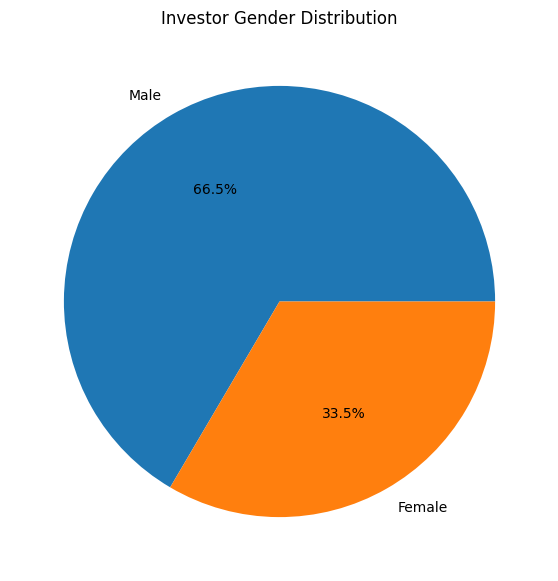

In [6]:
gender_distribution = (
    transactions["gender"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    gender_distribution,
    labels=gender_distribution.index,
    autopct="%1.1f%%"
)

plt.title(
    "Investor Gender Distribution"
)

plt.show()

### Insight:
Investor participation showed variation across gender segments, highlighting differences in mutual fund engagement and investment behaviour.

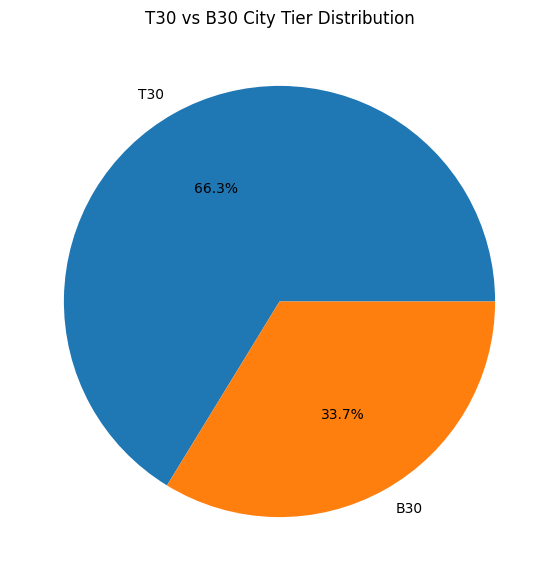

In [7]:
city_tier_distribution = (
    transactions["city_tier"]
    .value_counts()
)

plt.figure(figsize=(7,7))

plt.pie(
    city_tier_distribution,
    labels=city_tier_distribution.index,
    autopct="%1.1f%%"
)

plt.title(
    "T30 vs B30 City Tier Distribution"
)

plt.show()

### Insight:
T30 cities contributed significantly to mutual fund participation; however, B30 cities also showed meaningful investor growth, indicating increasing financial penetration beyond metro regions.